# Topic Modeling: Streaming App Reviews

Notebook ini menggunakan **Latent Dirichlet Allocation (LDA)** untuk extract topik tersembunyi dari review.

## Goal:
1. Identifikasi topik dominan di review NEGATIF (apa keluhan utama?)
2. Identifikasi topik dominan di review POSITIF (apa yang dipuji?)
3. Visualisasi interaktif topik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

sns.set_style('whitegrid')

# Load data
df = pd.read_csv('../data/reviews_preprocessed.csv')
df = df.dropna(subset=['review_stemmed'])
df = df[df['review_stemmed'].str.strip() != '']

print(f"📦 Total reviews: {len(df):,}")
print(f"📊 Per sentiment:")
print(df['sentiment'].value_counts())

📦 Total reviews: 9,305
📊 Per sentiment:
sentiment
negative    6488
positive    2086
neutral      731
Name: count, dtype: int64


#### 1. Topic Modeling untuk Review NEGATIF

Kita fokus dulu ke review negatif karena ini paling actionable untuk business.

In [2]:
# Filter review negatif
neg_reviews = df[df['sentiment'] == 'negative']['review_stemmed'].tolist()
print(f"📝 Total review negatif: {len(neg_reviews):,}")

# Tokenize (split jadi list of words)
neg_tokens = [str(text).split() for text in neg_reviews]

# Filter token: minimal 3 huruf
neg_tokens = [[w for w in doc if len(w) > 2] for doc in neg_tokens]

# Buat dictionary & corpus
dictionary_neg = corpora.Dictionary(neg_tokens)
# Filter kata yang muncul di < 10 dokumen atau > 50% dokumen
dictionary_neg.filter_extremes(no_below=10, no_above=0.5)

corpus_neg = [dictionary_neg.doc2bow(doc) for doc in neg_tokens]

print(f"📚 Vocabulary size: {len(dictionary_neg)}")
print(f"📄 Corpus size: {len(corpus_neg)}")

📝 Total review negatif: 6,488
📚 Vocabulary size: 764
📄 Corpus size: 6488


In [3]:
print("🚀 Training LDA model untuk review negatif (5 topik)...")

NUM_TOPICS = 5

lda_neg = LdaModel(
    corpus=corpus_neg,
    id2word=dictionary_neg,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("\n✅ Selesai! Topik yang ditemukan:\n")
for idx, topic in lda_neg.print_topics(num_words=10):
    print(f"🔴 Topic {idx + 1}:")
    print(f"   {topic}\n")

🚀 Training LDA model untuk review negatif (5 topik)...

✅ Selesai! Topik yang ditemukan:

🔴 Topic 1:
   0.062*"tidak" + 0.060*"langgan" + 0.059*"bayar" + 0.030*"aplikasi" + 0.029*"vip" + 0.022*"tonton" + 0.016*"mau" + 0.016*"saldo" + 0.015*"potong" + 0.013*"dana"

🔴 Topic 2:
   0.104*"aplikasi" + 0.066*"jelek" + 0.038*"bagus" + 0.036*"tidak" + 0.031*"banget" + 0.029*"buruk" + 0.023*"sering" + 0.018*"sangat" + 0.018*"wetv" + 0.018*"makin"

🔴 Topic 3:
   0.188*"iklan" + 0.055*"tonton" + 0.054*"banyak" + 0.041*"tidak" + 0.024*"banget" + 0.020*"menit" + 0.016*"film" + 0.016*"aplikasi" + 0.015*"kalau" + 0.012*"terlalu"

🔴 Topic 4:
   0.080*"tidak" + 0.035*"aplikasi" + 0.027*"padahal" + 0.025*"langgan" + 0.024*"buka" + 0.023*"beli" + 0.022*"tonton" + 0.019*"paket" + 0.019*"tiba" + 0.013*"malah"

🔴 Topic 5:
   0.113*"tidak" + 0.048*"login" + 0.047*"masuk" + 0.043*"mau" + 0.026*"susah" + 0.026*"otp" + 0.025*"daftar" + 0.025*"kode" + 0.024*"email" + 0.023*"aplikasi"



/var/folders/5b/yrqwlyzx3m31fvql5pr5s40c0000gn/T/ipykernel_1688/1943986297.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.barh(words, probs, color=plt.cm.get_cmap(cmap)(0.6))
/var/folders/5b/yrqwlyzx3m31fvql5pr5s40c0000gn/T/ipykernel_1688/1943986297.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.barh(words, probs, color=plt.cm.get_cmap(cmap)(0.6))
/var/folders/5b/yrqwlyzx3m31fvql5pr5s40c0000gn/T/ipykernel_1688/1943986297.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pypl

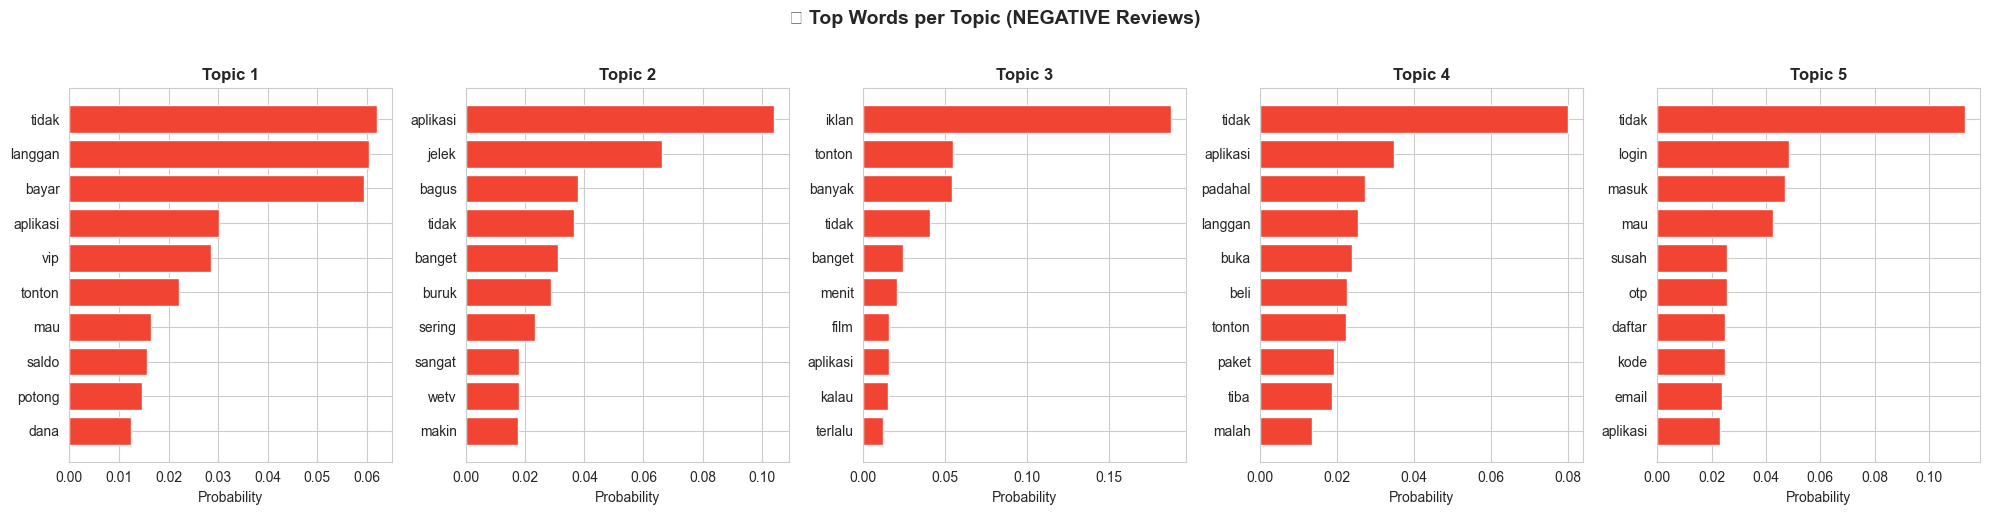

In [4]:
def plot_top_words(lda_model, num_topics, num_words=10, title='', cmap='Reds'):
    fig, axes = plt.subplots(1, num_topics, figsize=(20, 5), sharex=False)
    
    for i, ax in enumerate(axes):
        words_probs = lda_model.show_topic(i, topn=num_words)
        words = [w for w, p in words_probs][::-1]
        probs = [p for w, p in words_probs][::-1]
        
        ax.barh(words, probs, color=plt.cm.get_cmap(cmap)(0.6))
        ax.set_title(f'Topic {i+1}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Probability')
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_top_words(lda_neg, NUM_TOPICS, title='🔴 Top Words per Topic (NEGATIVE Reviews)', cmap='Reds')

#### 2. Topic Modeling untuk Review POSITIF

📝 Total review positif: 2,086

🚀 Training LDA model untuk review positif...

✅ Selesai! Topik yang ditemukan:

🟢 Topic 1:
   0.075*"film" + 0.054*"bagus" + 0.052*"aplikasi" + 0.046*"sangat" + 0.045*"tonton" + 0.032*"tidak" + 0.024*"suka" + 0.023*"good" + 0.019*"banyak" + 0.018*"buat"

🟢 Topic 2:
   0.051*"aplikasi" + 0.045*"viu" + 0.039*"tiba" + 0.033*"drama" + 0.032*"padahal" + 0.030*"bagus" + 0.029*"tidak" + 0.028*"paket" + 0.027*"suka" + 0.027*"data"

🟢 Topic 3:
   0.163*"iklan" + 0.066*"tidak" + 0.057*"banyak" + 0.028*"banget" + 0.027*"tonton" + 0.026*"rangin" + 0.024*"mau" + 0.022*"menit" + 0.022*"bayar" + 0.021*"kalau"

🟢 Topic 4:
   0.078*"tidak" + 0.061*"bagus" + 0.048*"tonton" + 0.038*"buka" + 0.035*"aplikasi" + 0.027*"apa" + 0.025*"viu" + 0.021*"banget" + 0.018*"terus" + 0.018*"mau"

🟢 Topic 5:
   0.047*"viu" + 0.043*"subtitle" + 0.034*"aplikasi" + 0.033*"tidak" + 0.030*"langsung" + 0.028*"bagus" + 0.027*"eror" + 0.027*"indo" + 0.025*"banget" + 0.022*"min"



/var/folders/5b/yrqwlyzx3m31fvql5pr5s40c0000gn/T/ipykernel_1688/1943986297.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.barh(words, probs, color=plt.cm.get_cmap(cmap)(0.6))
/var/folders/5b/yrqwlyzx3m31fvql5pr5s40c0000gn/T/ipykernel_1688/1943986297.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.barh(words, probs, color=plt.cm.get_cmap(cmap)(0.6))
/var/folders/5b/yrqwlyzx3m31fvql5pr5s40c0000gn/T/ipykernel_1688/1943986297.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pypl

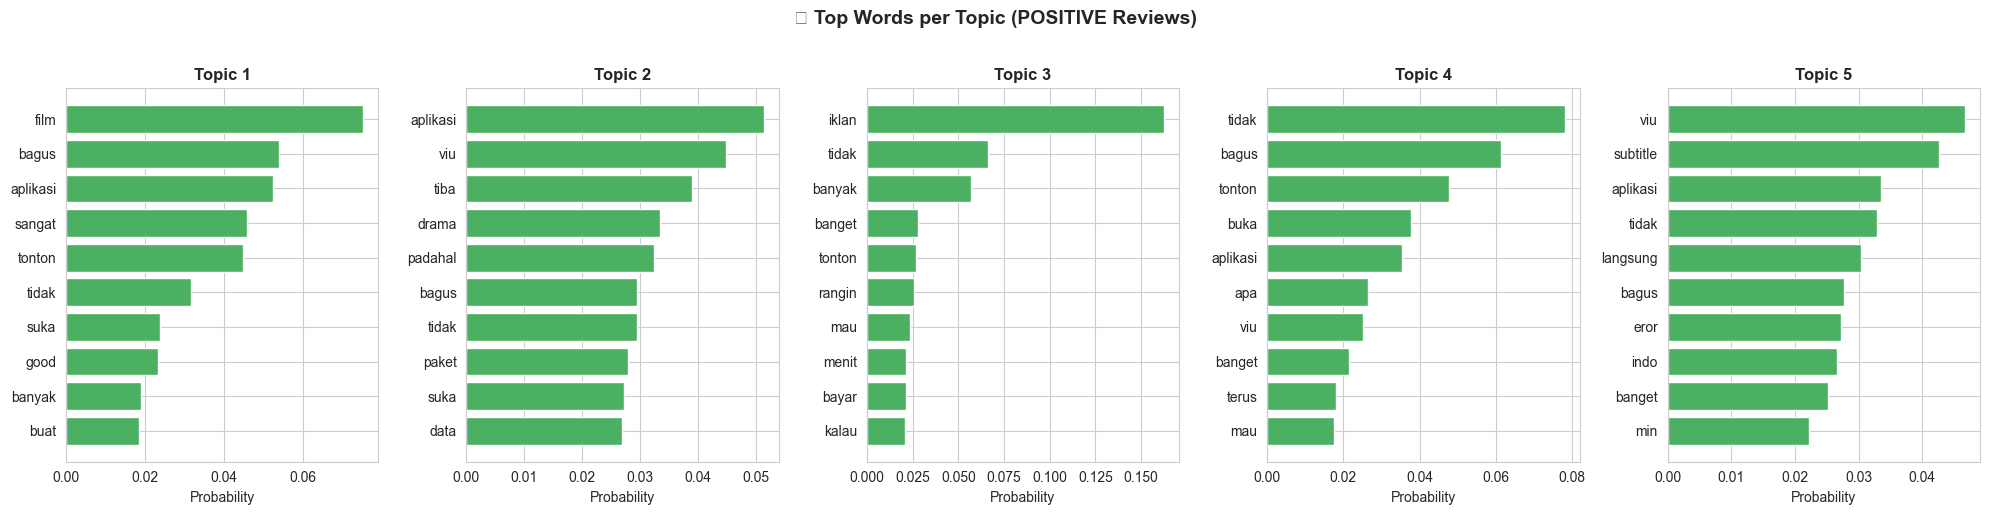

In [5]:
# Filter review positif
pos_reviews = df[df['sentiment'] == 'positive']['review_stemmed'].tolist()
print(f"📝 Total review positif: {len(pos_reviews):,}")

# Tokenize
pos_tokens = [str(text).split() for text in pos_reviews]
pos_tokens = [[w for w in doc if len(w) > 2] for doc in pos_tokens]

# Dictionary & corpus
dictionary_pos = corpora.Dictionary(pos_tokens)
dictionary_pos.filter_extremes(no_below=10, no_above=0.5)
corpus_pos = [dictionary_pos.doc2bow(doc) for doc in pos_tokens]

# Train LDA
print("\n🚀 Training LDA model untuk review positif...")
lda_pos = LdaModel(
    corpus=corpus_pos,
    id2word=dictionary_pos,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("\n✅ Selesai! Topik yang ditemukan:\n")
for idx, topic in lda_pos.print_topics(num_words=10):
    print(f"🟢 Topic {idx + 1}:")
    print(f"   {topic}\n")

# Visualize
plot_top_words(lda_pos, NUM_TOPICS, title='🟢 Top Words per Topic (POSITIVE Reviews)', cmap='Greens')

#### 3. Interactive Visualization dengan pyLDAvis

Visualisasi interaktif yang menampilkan posisi topik di 2D space + top words per topic.

In [6]:
# Prepare visualization
pyLDAvis.enable_notebook()
vis_neg = gensimvis.prepare(lda_neg, corpus_neg, dictionary_neg)

# Save sebagai HTML (bisa dibuka di browser)
pyLDAvis.save_html(vis_neg, '../results/lda_negative_topics.html')
print("💾 Saved: ../results/lda_negative_topics.html")

# Tampilkan di notebook
vis_neg

💾 Saved: ../results/lda_negative_topics.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.063623 -0.257814       1        1  28.205610
3     -0.047495  0.042133       2        1  26.394163
4     -0.205064  0.095848       3        1  19.639622
0     -0.050095 -0.032564       4        1  16.783974
1      0.239031  0.152397       5        1   8.976631, topic_info=         Term         Freq        Total Category  logprob  loglift
67      iklan  3524.000000  3524.000000  Default  30.0000  30.0000
21   aplikasi  2164.000000  2164.000000  Default  29.0000  29.0000
105    banyak  1015.000000  1015.000000  Default  28.0000  28.0000
15      login   634.000000   634.000000  Default  27.0000  27.0000
25      jelek   403.000000   403.000000  Default  26.0000  26.0000
..        ...          ...          ...      ...      ...      ...
65       film    52.432702   535.364336   Topic5  -4.7360   0.0871
18       mulu    44.885564   200.169227   Topic5  -4.8914   0.9155
77     tonton    58.839318  1727.077525   Topic5  -4.6207  -0.9688
9     padahal    52.314991   736.873985   Topic5  -4.7382  -0.2346
92      terus    49.348874   489.845859   Topic5  -4.7966   0.1154

[313 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
524       2  0.988748    aktif
104       2  0.003660     akun
104       3  0.896700     akun
104       4  0.098820     akun
319       2  0.938781     aman
...     ...       ...      ...
709       2  0.966090  voucher
742       1  0.975561    wajar
759       5  0.994963     wetv
270       2  0.968232     wifi
270       3  0.023809     wifi

[487 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 5, 1, 2])

In [7]:
vis_pos = gensimvis.prepare(lda_pos, corpus_pos, dictionary_pos)
pyLDAvis.save_html(vis_pos, '../results/lda_positive_topics.html')
print("💾 Saved: ../results/lda_positive_topics.html")

vis_pos

💾 Saved: ../results/lda_positive_topics.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.116115  0.231996       1        1  41.509032
3      0.001743 -0.087481       2        1  20.608875
2      0.185279 -0.141285       3        1  16.490208
1     -0.164077  0.042285       4        1  10.754937
4     -0.139060 -0.045514       5        1  10.636947, topic_info=        Term        Freq       Total Category  logprob  loglift
150    iklan  396.000000  396.000000  Default  30.0000  30.0000
4       film  428.000000  428.000000  Default  29.0000  29.0000
27    banyak  238.000000  238.000000  Default  28.0000  28.0000
253      viu  216.000000  216.000000  Default  27.0000  27.0000
17    sangat  258.000000  258.000000  Default  26.0000  26.0000
..       ...         ...         ...      ...      ...      ...
79     kalau   23.487539  128.549006   Topic5  -4.0764   0.5410
46       mau   23.299502  128.905675   Topic5  -4.0844   0.5302
28   bintang   21.565338  102.099573   Topic5  -4.1618   0.6860
273    paket   19.617027   69.956897   Topic5  -4.2565   0.9694
63     malah   19.768622   74.846395   Topic5  -4.2488   0.9095

[277 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
279       5  0.984196  adain
146       1  0.038568  akhir
146       2  0.964197  akhir
119       4  0.923282  aktif
260       2  0.991936   akun
...     ...       ...    ...
97        2  0.401356    yaa
97        3  0.221438    yaa
97        4  0.166078    yaa
97        5  0.193758    yaa
115       3  0.922446    you

[398 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 3, 2, 5])

## 4. Interpretasi Topik

###  Review NEGATIF:
- **Topic 1: Pembayaran & Langganan** — keluhan VIP, saldo terpotong, biaya
- **Topic 2: Kualitas Aplikasi Buruk** — feedback umum aplikasi jelek
- **Topic 3: Iklan Berlebihan** — iklan terlalu sering saat menonton
- **Topic 4: Konten Tidak Bisa Diakses** — sudah bayar tapi tidak bisa nonton
- **Topic 5: Login & OTP Issues** — masalah authentication

### Review POSITIF:
- **Topic 1: Apresiasi Umum** — pujian general film & app
- **Topic 2: Drama Asia di Viu** — puas dengan konten Korea/Asia
- **Topic 3: Mentions Iklan** — kemungkinan sarkasme/mixed feeling
- **Topic 4: Performa Lancar** — app responsive & smooth
- **Topic 5: Subtitle Indonesia** — apresiasi subtitle berkualitas

### Business Insight Utama:
**5 pillar masalah** yang harus diatasi platform streaming Indonesia:
1. Sistem pembayaran transparan (no hidden charges)
2. Reduce ad frequency
3. Konten yang sudah dibayar harus accessible
4. Login/OTP system yang reliable
5. Kualitas subtitle Indonesia (peluang differensiasi!)